In [1]:
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Activation, SpatialDropout2D
from tensorflow.keras.applications import  InceptionV3, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils import class_weight
from keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.preprocessing.image import img_to_array, load_img


2026-05-23 02:28:34.342929: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779503314.564905      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779503314.629567      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779503315.170864      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779503315.170906      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779503315.170909      23 computation_placer.cc:177] computation placer alr

In [2]:
# Using Kaggle Path
data_dir = '/kaggle/input/datasets/sujaykapadnis/banana-disease-recognition-dataset/Banana Disease Recognition Dataset/Augmented images/Augmented images'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Advanced Data Augmentation for Training
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# rescaling for validation
datagen_val = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen_train.flow_from_directory(
    data_dir, 
    target_size=IMG_SIZE, 
    batch_size=BATCH_SIZE, 
    class_mode='categorical', 
    subset='training'
)

val_generator = datagen_val.flow_from_directory(
    data_dir, 
    target_size=IMG_SIZE, 
    batch_size=BATCH_SIZE, 
    class_mode='categorical', 
    subset='validation',
    shuffle=False
)


Found 2287 images belonging to 7 classes.
Found 569 images belonging to 7 classes.


In [3]:
# Compute class weights to handle any class imbalance
class_weights = class_weight.compute_class_weight(
    'balanced', 
    classes=np.unique(train_generator.classes), 
    y=train_generator.classes
)
class_weights = {i : class_weights[i] for i in range(len(class_weights))}
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.868920972644377), 1: np.float64(1.1668367346938775), 2: np.float64(0.6778304682868999), 3: np.float64(0.6778304682868999), 4: np.float64(1.060760667903525), 5: np.float64(1.4204968944099379), 6: np.float64(2.532668881506091)}


In [4]:
# Define callbacks for robust training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]


In [5]:
# 1. Custom CNN Model
L2 = regularizers.l2(1e-4)

model_custom = Sequential([

    # ============ Block 1: 32 filters ============
    Conv2D(32, (3,3), padding='same', use_bias=False, kernel_initializer='he_normal', kernel_regularizer=L2, input_shape=(224, 224, 3)),
    BatchNormalization(),          
    Activation('relu'),

    Conv2D(32, (3,3), padding='same', use_bias=False, kernel_initializer='he_normal', kernel_regularizer=L2),
    BatchNormalization(),          
    Activation('relu'),

    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.1),        


    # ============ Block 2: 64 filters ============
    Conv2D(64, (3,3), padding='same', use_bias=False, kernel_initializer='he_normal', kernel_regularizer=L2),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(64, (3,3), padding='same', use_bias=False, kernel_initializer='he_normal', kernel_regularizer=L2),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.1),


    # ============ Block 3: 128 filters ============
    Conv2D(128, (3,3), padding='same', use_bias=False, kernel_initializer='he_normal', kernel_regularizer=L2),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(128, (3,3), padding='same', use_bias=False, kernel_initializer='he_normal', kernel_regularizer=L2),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.1),


    # ============ Block 4: 256 filters ============
    Conv2D(256, (3,3), padding='same', use_bias=False,    kernel_initializer='he_normal', kernel_regularizer=L2),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(256, (3,3), padding='same', use_bias=False,  kernel_initializer='he_normal', kernel_regularizer=L2),
    BatchNormalization(),
    Activation('relu'),

    GlobalAveragePooling2D(),
    


    # ============ MLP Head ============
    Dense(256, use_bias=False, kernel_regularizer=L2),
    BatchNormalization(),          
    Activation('relu'),
    Dropout(0.4),                  

    Dense(128, use_bias=False, kernel_regularizer=L2),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),                  

    Dense(7, activation='softmax') 
])

model_custom.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model_custom.summary()


I0000 00:00:1779503344.317473      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779503344.323295      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 112, 112, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 56, 56, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,275,879 (4.87 MB)

 Trainable params: 1,273,191 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [6]:
print("Training Custom CNN...")
history_custom = model_custom.fit(
    train_generator, 
    epochs=50, 
    validation_data=val_generator, 
    class_weight=class_weights,
    callbacks=callbacks
)


Training Custom CNN...
Epoch 1/50


I0000 00:00:1779503352.810535      86 service.cc:152] XLA service 0x7e1dcc00d5a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779503352.810574      86 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779503352.810578      86 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779503353.921111      86 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-23 02:29:21.042192: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 02:29:21.196182: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 02:29:24.221012: E external/local_xl

 1/72 ━━━━━━━━━━━━━━━━━━━━ 33:23 28s/step - accuracy: 0.3438 - loss: 2.8415

I0000 00:00:1779503374.952988      86 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/72 ━━━━━━━━━━━━━━━━━━━━ 25s 470ms/step - accuracy: 0.3077 - loss: 2.3772

2026-05-23 02:29:47.191433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 02:29:47.340917: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 02:29:48.920734: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 02:29:49.202269: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


72/72 ━━━━━━━━━━━━━━━━━━━━ 86s 808ms/step - accuracy: 0.3750 - loss: 1.9765 - val_accuracy: 0.3937 - val_loss: 1.8862 - learning_rate: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 425ms/step - accuracy: 0.4918 - loss: 1.4538 - val_accuracy: 0.4675 - val_loss: 1.6514 - learning_rate: 0.0010
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 425ms/step - accuracy: 0.5481 - loss: 1.3536 - val_accuracy: 0.6714 - val_loss: 1.3701 - learning_rate: 0.0010
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 423ms/step - accuracy: 0.5772 - loss: 1.2777 - val_accuracy: 0.6538 - val_loss: 1.2653 - learning_rate: 0.0010
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 425ms/step - accuracy: 0.6227 - loss: 1.2045 - val_accuracy: 0.6907 - val_loss: 1.0895 - learning_rate: 0.0010
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 416ms/step - accuracy: 0.6362 - loss: 1.1489 - val_accuracy: 0.6520 - val_loss: 1.3770 - learning_rate: 0.0010
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 422ms/step - accuracy: 0.6992 - loss: 1.0585 - val_

In [7]:
base_model_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning: Unfreeze the top layers
base_model_res.trainable = True
for layer in base_model_res.layers[:-20]: # Freeze all but last 20 layers
    layer.trainable = False

model_res = Sequential([
    base_model_res,
    GlobalAveragePooling2D(),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(7, activation='softmax')
])

# Use lower learning rate for fine-tuning
model_res.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model_res.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,399 (90.99 MB)

 Trainable params: 9,194,759 (35.08 MB)

 Non-trainable params: 14,656,640 (55.91 MB)

In [8]:
print("Training ResNet50...")
history_eff = model_res.fit(
    train_generator, 
    epochs=50, 
    validation_data=val_generator, 
    class_weight=class_weights,
    callbacks=callbacks
)


Training ResNet50...
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 621ms/step - accuracy: 0.2956 - loss: 2.1279 - val_accuracy: 0.2109 - val_loss: 2.0780 - learning_rate: 1.0000e-04
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 417ms/step - accuracy: 0.3921 - loss: 1.6465 - val_accuracy: 0.2109 - val_loss: 1.9451 - learning_rate: 1.0000e-04
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 418ms/step - accuracy: 0.4592 - loss: 1.4201 - val_accuracy: 0.2109 - val_loss: 1.9259 - learning_rate: 1.0000e-04
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 414ms/step - accuracy: 0.5255 - loss: 1.2515 - val_accuracy: 0.3515 - val_loss: 2.0352 - learning_rate: 1.0000e-04
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 409ms/step - accuracy: 0.5033 - loss: 1.2402 - val_accuracy: 0.2232 - val_loss: 2.0141 - learning_rate: 1.0000e-04
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.5274 - loss: 1.2291
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 4

In [9]:
# 3. InceptionV3 Model
base_model_inc = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning: Unfreeze the top layers
base_model_inc.trainable = True
for layer in base_model_inc.layers[:-30]: # Freeze all but last 30 layers
    layer.trainable = False

model_inc = Sequential([
    base_model_inc,
    GlobalAveragePooling2D(),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(7, activation='softmax')
])

# Use lower learning rate for fine-tuning
model_inc.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model_inc.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_105         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,066,471 (84.18 MB)

 Trainable params: 5,419,463 (20.67 MB)

 Non-trainable params: 16,647,008 (63.50 MB)

In [10]:
print("Training InceptionV3...")
history_inc = model_inc.fit(
    train_generator, 
    epochs=50, 
    validation_data=val_generator, 
    class_weight=class_weights,
    callbacks=callbacks
)


Training InceptionV3...
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 74s 719ms/step - accuracy: 0.4264 - loss: 1.8828 - val_accuracy: 0.6766 - val_loss: 0.8714 - learning_rate: 1.0000e-04
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 410ms/step - accuracy: 0.7953 - loss: 0.6076 - val_accuracy: 0.8453 - val_loss: 0.5023 - learning_rate: 1.0000e-04
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 413ms/step - accuracy: 0.8653 - loss: 0.4076 - val_accuracy: 0.8998 - val_loss: 0.3406 - learning_rate: 1.0000e-04
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 404ms/step - accuracy: 0.8917 - loss: 0.3243 - val_accuracy: 0.9069 - val_loss: 0.2681 - learning_rate: 1.0000e-04
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 403ms/step - accuracy: 0.9119 - loss: 0.2883 - val_accuracy: 0.8858 - val_loss: 0.3158 - learning_rate: 1.0000e-04
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 405ms/step - accuracy: 0.9214 - loss: 0.2305 - val_accuracy: 0.9156 - val_loss: 0.2493 - learning_rate: 1.0000e-04
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━

In [11]:
def plot_performance(history, title):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

def evaluate_model(model, generator):
    y_true = generator.classes
    y_pred = model.predict(generator)
    y_pred_classes = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(y_true, y_pred_classes)
    cr = classification_report(y_true, y_pred_classes, target_names=generator.class_indices.keys())

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=generator.class_indices.keys(), yticklabels=generator.class_indices.keys())
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    print('Classification Report:\n', cr)


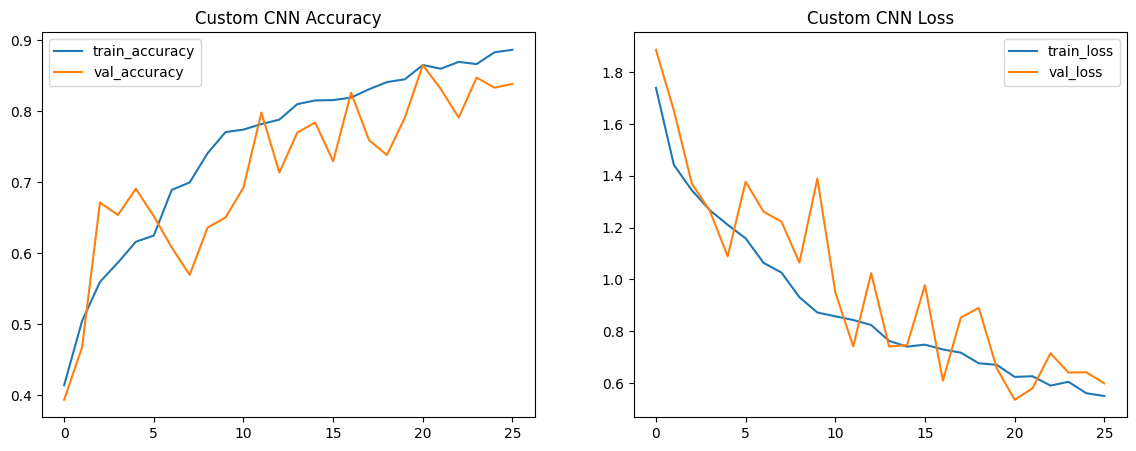

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step
Classification Report:
                                              precision    recall  f1-score   support

    Augmented Banana Black Sigatoka Disease       0.83      0.73      0.78        93
Augmented Banana Bract Mosaic Virus Disease       0.72      0.83      0.77        70
              Augmented Banana Healthy Leaf       0.96      1.00      0.98       120
       Augmented Banana Insect Pest Disease       0.85      0.93      0.89       120
              Augmented Banana Moko Disease       0.87      0.71      0.79        77
            Augmented Banana Panama Disease       0.85      0.82      0.84        57
   Augmented Banana Yellow Sigatoka Disease       1.00      1.00      1.00        32

                                   accuracy                           0.86       569
                                  macro avg       0.87      0.86      0.86       569
                               weighted avg       0.87      0.86      0.86       56

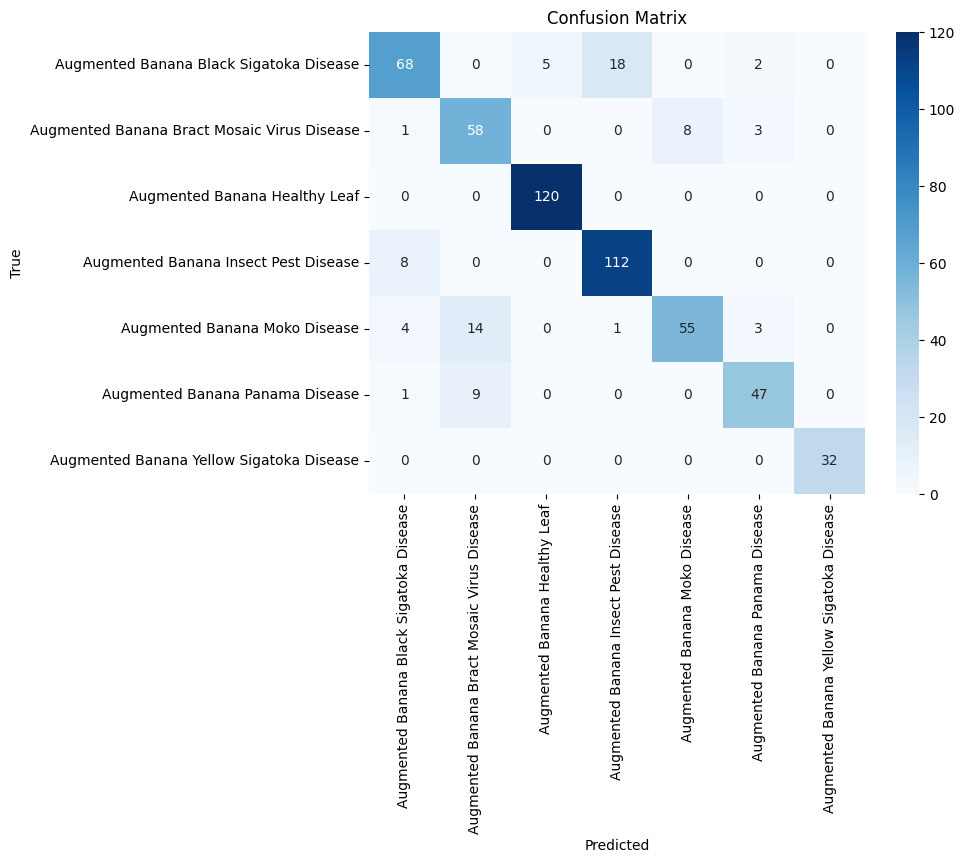

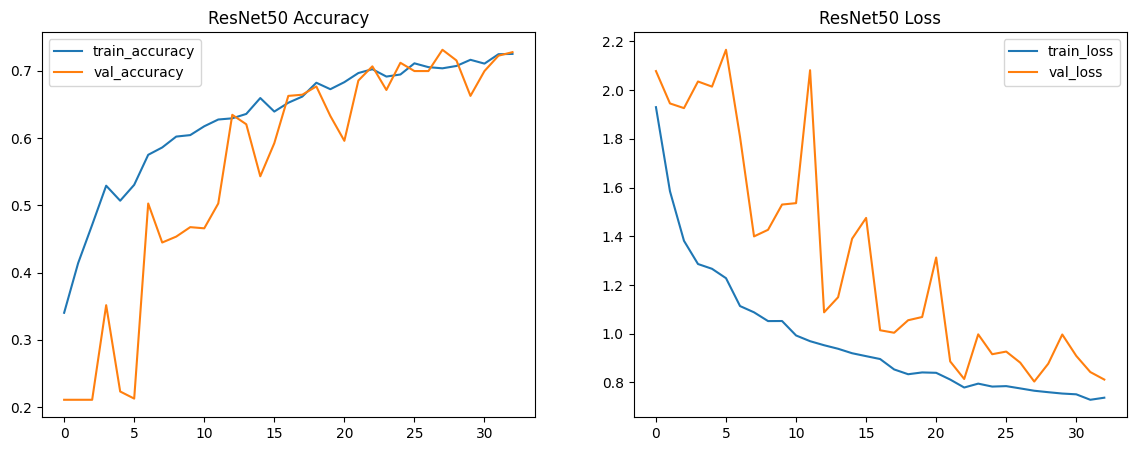

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 306ms/step
Classification Report:
                                              precision    recall  f1-score   support

    Augmented Banana Black Sigatoka Disease       0.78      0.30      0.43        93
Augmented Banana Bract Mosaic Virus Disease       0.76      0.84      0.80        70
              Augmented Banana Healthy Leaf       0.88      0.88      0.88       120
       Augmented Banana Insect Pest Disease       0.66      0.77      0.71       120
              Augmented Banana Moko Disease       0.68      0.65      0.67        77
            Augmented Banana Panama Disease       0.64      0.88      0.74        57
   Augmented Banana Yellow Sigatoka Disease       0.70      0.97      0.82        32

                                   accuracy                           0.73       569
                                  macro avg       0.73      0.76      0.72       569
                               weighted avg       0.74      0.73      0.71       56

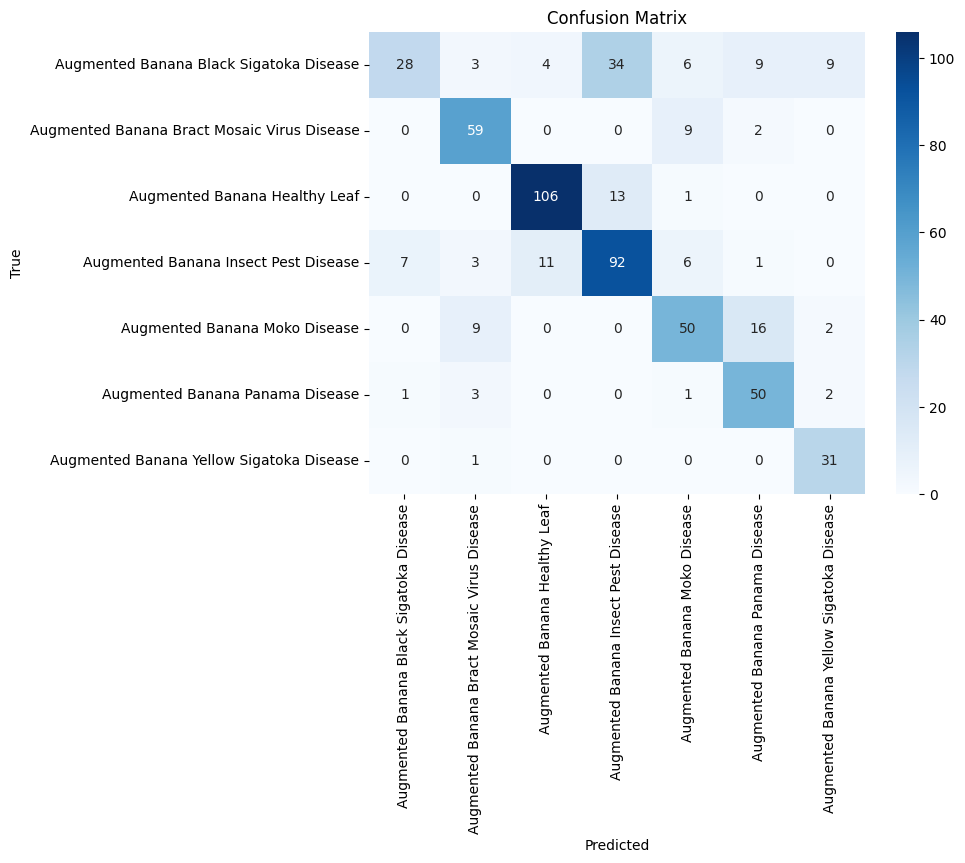

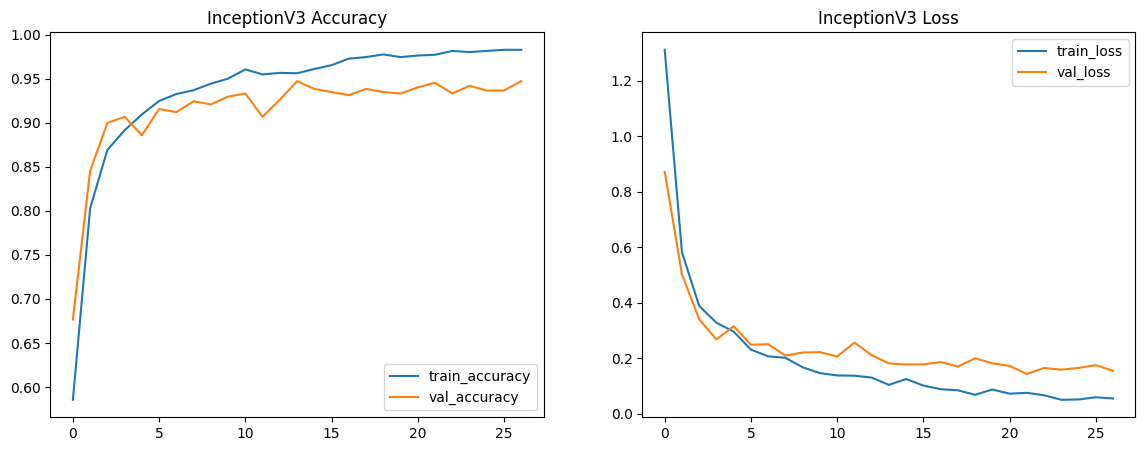

18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step
Classification Report:
                                              precision    recall  f1-score   support

    Augmented Banana Black Sigatoka Disease       0.90      0.90      0.90        93
Augmented Banana Bract Mosaic Virus Disease       0.97      0.99      0.98        70
              Augmented Banana Healthy Leaf       1.00      1.00      1.00       120
       Augmented Banana Insect Pest Disease       0.94      0.97      0.95       120
              Augmented Banana Moko Disease       0.93      0.87      0.90        77
            Augmented Banana Panama Disease       0.88      0.93      0.91        57
   Augmented Banana Yellow Sigatoka Disease       0.97      0.91      0.94        32

                                   accuracy                           0.95       569
                                  macro avg       0.94      0.94      0.94       569
                               weighted avg       0.95      0.95      0.95       5

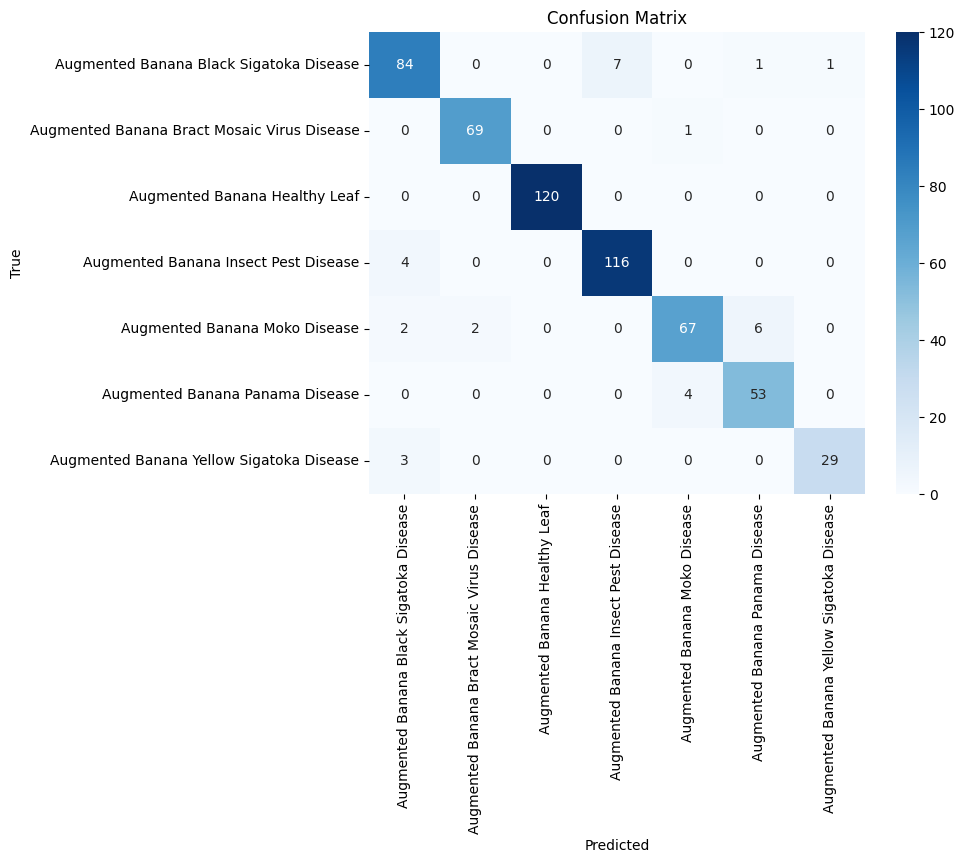

In [12]:
# Custom CNN Eval
plot_performance(history_custom, 'Custom CNN')
evaluate_model(model_custom, val_generator)

# EfficientNetB0 Eval
plot_performance(history_eff, 'ResNet50')
evaluate_model(model_res, val_generator)

# InceptionV3 Eval
plot_performance(history_inc, 'InceptionV3')
evaluate_model(model_inc, val_generator)


In [13]:
model_custom.save('model_custom.h5')
model_res.save('model_res.h5')
model_inc.save('model_inception.h5')


In [ ]:
import numpy as np
import io
import requests
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array

def preprocess_image(image_input, target_size=(224, 224)):

    # CASE 1: URL
    if isinstance(image_input, str) and image_input.startswith("http"):
        response = requests.get(image_input)
        img = Image.open(io.BytesIO(response.content)).convert("RGB")

    # CASE 2: bytes (Swagger / phone upload / FastAPI)
    elif isinstance(image_input, (bytes, bytearray)):
        img = Image.open(io.BytesIO(image_input)).convert("RGB")

    # CASE 3: local file path (Kaggle / local testing)
    else:
        img = Image.open(image_input).convert("RGB")

    img = img.resize(target_size)

    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    return img_array

class_mapping = {v: k for k, v in train_generator.class_indices.items()}

# Function to predict using each model and aggregate predictions
def predict_with_voting(image_path):
    img = preprocess_image(image_path)
    
    # Step 1: Make predictions using each model
    pred_custom = model_custom.predict(img)
    pred_inc = model_inc.predict(img)
    
    final_pred_prob = pred_custom * 0.4 + pred_inc * 0.6

    # Step 3: Predict class
    final_pred_class = np.argmax(final_pred_prob, axis=1)
    
    # Map index to disease
    final_pred_disease = [class_mapping[class_index] for class_index in final_pred_class]

   
    result = final_pred_disease[0].replace("Augmented ", "")
    return result




print(predict_with_voting('/kaggle/input/datasets/shifatearman/bananalsd/BananaLSD/OriginalSet/healthy/117.jpeg'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Banana Healthy Leaf
